In [1]:
pip install torchaudio

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import os
os.path.exists("/content/drive/MyDrive/fan/id_00/normal/00000000.wav")

True

In [2]:
import torchaudio
import torchaudio.transforms as T

waveform, sample_rate = torchaudio.load("/content/drive/MyDrive/fan/id_00/normal/00000000.wav")

mel_transform = T.MelSpectrogram(
    sample_rate=sample_rate,
    n_fft=1024,
    hop_length=512,
    n_mels=128
)

# Convert to log scale (matches human hearing perception)
mel_spec = mel_transform(waveform)          # shape: [channels, n_mels, time_frames]
log_mel   = T.AmplitudeToDB()(mel_spec)     # shape: [1, 128, T]  ← this is your tensor

In [3]:
import torchaudio
import matplotlib.pyplot as plt
import glob

wav_files = glob.glob("/content/drive/MyDrive/fan/id_00/normal/*.wav")


# 1. Check durations — are they consistent?
for f in wav_files:
    waveform, sample_rate = torchaudio.load(f)
    duration = waveform.shape[-1] / sample_rate
    print(f"{f}: {duration:.2f}s, sr={sample_rate}, shape={waveform.shape}")

# 2. Visualize a spectrogram
#plt.imshow(log_mel[0].numpy(), origin='lower', aspect='auto')
#plt.colorbar(); plt.title("Log-Mel Spectrogram"); plt.show()

# 3. Check sample rates — are they all the same?
# If not, resample everything to a common rate (e.g. 16kHz or 22050Hz)
#resample = T.Resample(orig_freq=44100, new_freq=16000)

/content/drive/MyDrive/fan/id_00/normal/00000023.wav: 10.00s, sr=16000, shape=torch.Size([8, 160000])
/content/drive/MyDrive/fan/id_00/normal/00000035.wav: 10.00s, sr=16000, shape=torch.Size([8, 160000])
/content/drive/MyDrive/fan/id_00/normal/00000029.wav: 10.00s, sr=16000, shape=torch.Size([8, 160000])
/content/drive/MyDrive/fan/id_00/normal/00000021.wav: 10.00s, sr=16000, shape=torch.Size([8, 160000])
/content/drive/MyDrive/fan/id_00/normal/00000025.wav: 10.00s, sr=16000, shape=torch.Size([8, 160000])
/content/drive/MyDrive/fan/id_00/normal/00000033.wav: 10.00s, sr=16000, shape=torch.Size([8, 160000])
/content/drive/MyDrive/fan/id_00/normal/00000027.wav: 10.00s, sr=16000, shape=torch.Size([8, 160000])
/content/drive/MyDrive/fan/id_00/normal/00000041.wav: 10.00s, sr=16000, shape=torch.Size([8, 160000])
/content/drive/MyDrive/fan/id_00/normal/00000051.wav: 10.00s, sr=16000, shape=torch.Size([8, 160000])
/content/drive/MyDrive/fan/id_00/normal/00000045.wav: 10.00s, sr=16000, shape=torc

RuntimeError: Failed to decode audio samples: decodeAVFrame, /__w/torchcodec/torchcodec/meta-pytorch/torchcodec/src/torchcodec/_core/SingleStreamDecoder.cpp:1381, Could not read frame from input file: Transport endpoint is not connected

In [6]:
for f in wav_files:
    try:
        waveform, sample_rate = torchaudio.load(f)
        duration = waveform.shape[-1] / sample_rate
        print(f"OK | {f}: {duration:.2f}s, sr={sample_rate}")
    except Exception as e:
        print(f"ERROR | {f}: {e}")

OK | /content/drive/MyDrive/fan/id_00/normal/00000023.wav: 10.00s, sr=16000
OK | /content/drive/MyDrive/fan/id_00/normal/00000035.wav: 10.00s, sr=16000
OK | /content/drive/MyDrive/fan/id_00/normal/00000029.wav: 10.00s, sr=16000
OK | /content/drive/MyDrive/fan/id_00/normal/00000021.wav: 10.00s, sr=16000
OK | /content/drive/MyDrive/fan/id_00/normal/00000025.wav: 10.00s, sr=16000
OK | /content/drive/MyDrive/fan/id_00/normal/00000033.wav: 10.00s, sr=16000
OK | /content/drive/MyDrive/fan/id_00/normal/00000027.wav: 10.00s, sr=16000
OK | /content/drive/MyDrive/fan/id_00/normal/00000041.wav: 10.00s, sr=16000
OK | /content/drive/MyDrive/fan/id_00/normal/00000051.wav: 10.00s, sr=16000
OK | /content/drive/MyDrive/fan/id_00/normal/00000045.wav: 10.00s, sr=16000
OK | /content/drive/MyDrive/fan/id_00/normal/00000037.wav: 10.00s, sr=16000
OK | /content/drive/MyDrive/fan/id_00/normal/00000049.wav: 10.00s, sr=16000
OK | /content/drive/MyDrive/fan/id_00/normal/00000043.wav: 10.00s, sr=16000
OK | /conten

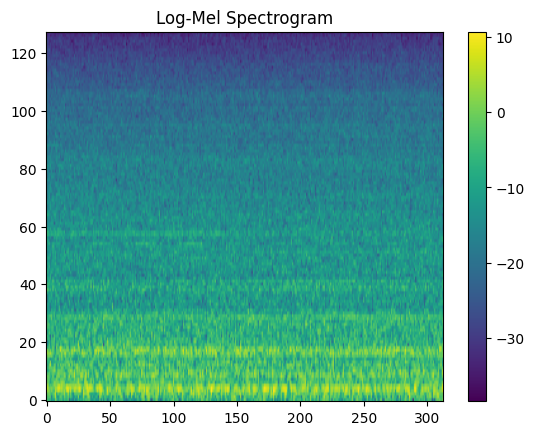

In [8]:
import matplotlib.pyplot as plt

plt.imshow(log_mel[7].numpy(), origin='lower', aspect='auto')
plt.colorbar(); plt.title("Log-Mel Spectrogram"); plt.show()
